In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point


In [2]:
# Load Flood Data
gdf_flood = gpd.read_file('../data/flood shapefile/bgd_nhr_floods_sparsso.shp')
# Normalise intensity (Severity mapping: 0→0, Severe→1.0, Moderate→0.6, Low→0.3)
flood_intensity = {0:0.0, 1:1.0, 2:0.6, 3:0.3, 4:1.0, 5:0.6, 6:0.3, 7:1.0, 8:0.6}
gdf_flood['flood_hazard_val'] = gdf_flood['FLOODCAT'].astype(int).map(flood_intensity)

# Load Earthquake Data
gdf_eq = gpd.read_file('../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp')
eq_hazard_map = {'I': 1.0, 'II': 0.6, 'III': 0.3}
gdf_eq['eq_hazard_val'] = gdf_eq['ZONE'].map(eq_hazard_map).fillna(0.3)

print(f"Flood: {len(gdf_flood)} polygons; EQ: {len(gdf_eq)} polygons.")

Flood: 4440 polygons; EQ: 142 polygons.


## Spatial join

In [5]:
# 1. Load your network structure
df_net = pd.read_csv('..data/df_road.csv')

# 2. Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_net['lon'], df_net['lat'])]
gdf_roads = gpd.GeoDataFrame(df_net, geometry=geometry, crs="EPSG:4326")

# 3. Perform Spatial Joins (with the index_right fix)
gdf_roads = gpd.sjoin(gdf_roads, gdf_flood[['geometry', 'flood_hazard_val', 'FLOODCAT']],
                      how='left', predicate='intersects')
if 'index_right' in gdf_roads.columns: # FIX: Remove 'index_right' so the next join doesn't crash
    gdf_roads = gdf_roads.drop(columns=['index_right'])

gdf_roads = gpd.sjoin(gdf_roads, gdf_eq[['geometry', 'eq_hazard_val', 'ZONE']],
                      how='left', predicate='intersects')

gdf_roads = gdf_roads.rename(columns={
    'flood_hazard_val': 'flood_hazard',
    'eq_hazard_val': 'eq_hazard',
    'ZONE': 'eq_zone',
    'FLOODCAT': 'flood_cat'
})

FileNotFoundError: [Errno 2] No such file or directory: '..data/df_road.csv'

In [8]:
gdf_roads

,Unnamed: 0,length,condition,lat,lon,intersection,model_type,id,road,name,geometry,flood_hazard,flood_cat,index_right,eq_hazard,eq_zone
0,0,4.0,NaN,23.706028,90.443333,NaN,sourcesink,10000,N1,NaN,POINT (90.44333 23.70603),0.0,0.0,0.0,0.6,II
1,1,1800.0,NaN,23.702383,90.451097,0,link,10001,N1,NaN,POINT (90.4511 23.70238),0.0,0.0,0.0,0.6,II
2,2,11.3,A,23.698739,90.458861,NaN,bridge,10002,N1,NaN,POINT (90.45886 23.69874),0.0,0.0,0.0,0.6,II
3,3,3125.0,NaN,23.696701,90.473318,0,link,10003,N1,NaN,POINT (90.47332 23.6967),0.0,0.0,0.0,0.6,II
4,4,6.6,A,23.694664,90.487775,NaN,bridge,10004,N1,NaN,POINT (90.48777 23.69466),0.0,0.0,0.0,0.6,II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2795,4.2,A,21.430527,91.976166,NaN,bridge,12795,N110,NaN,POINT (91.97617 21.43053),0.6,5.0,0.0,0.6,II
2796,2796,613.0,NaN,21.431587,91.975161,0,link,12796,N110,NaN,POINT (91.97516 21.43159),0.6,5.0,0.0,0.6,II
2797,2797,9.4,A,21.432647,91.974157,NaN,bridge,12797,N110,NaN,POINT (91.97416 21.43265),0.6,5.0,0.0,0.6,II
2798,2798,1160.0,NaN,21.434323,91.972870,0,link,12798,N110,NaN,POINT (91.97287 21.43432),0.6,5.0,0.0,0.6,II


## Vulnerability score

In [16]:
# 1. Map Internal Condition (A-D) to Scores 1-4
cond_to_score = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
gdf_roads['int_cond_score'] = gdf_roads['condition'].map(cond_to_score).fillna(1)

# 2. Assign Multipliers for Environmental Hazards
# Earthquake Seismic Multiplier (Zone I=1.0, II=1.5, III=2.0)
seismic_map = {'I': 1.0, 'II': 1.5, 'III': 2.0}
gdf_roads['seismic_mult'] = gdf_roads['eq_zone'].map(seismic_map).fillna(1.0)

# Flood Hazard Multiplier
# Using  FLOODCAT normalisation logic from the script: max severity = 2.0x
# Mapping flood_hazard (0-1) to a multiplier (1.0 to 2.0)
gdf_roads['flood_mult'] = 1.0 + gdf_roads['flood_hazard']

# 3. Calculate Final Integrated Vulnerability Score
# We take the maximum multiplier between Flood and EQ to find the dominant threat
gdf_roads['max_hazard_mult'] = gdf_roads[['seismic_mult', 'flood_mult']].max(axis=1)

# Final Formula: Internal Condition Score * Maximum Environmental Hazard
gdf_roads['vulnerability_score'] = gdf_roads['int_cond_score'] * gdf_roads['max_hazard_mult']

gdf_roads

,Unnamed: 0,length,condition,lat,lon,intersection,model_type,id,road,name,...,flood_hazard,flood_cat,index_right,eq_hazard,eq_zone,int_cond_score,seismic_mult,flood_mult,max_hazard_mult,vulnerability_score
0,0,4.0,NaN,23.706028,90.443333,NaN,sourcesink,10000,N1,NaN,...,0.0,0.0,0.0,0.6,II,1.0,1.5,1.0,1.5,1.5
1,1,1800.0,NaN,23.702383,90.451097,0,link,10001,N1,NaN,...,0.0,0.0,0.0,0.6,II,1.0,1.5,1.0,1.5,1.5
2,2,11.3,A,23.698739,90.458861,NaN,bridge,10002,N1,NaN,...,0.0,0.0,0.0,0.6,II,1.0,1.5,1.0,1.5,1.5
3,3,3125.0,NaN,23.696701,90.473318,0,link,10003,N1,NaN,...,0.0,0.0,0.0,0.6,II,1.0,1.5,1.0,1.5,1.5
4,4,6.6,A,23.694664,90.487775,NaN,bridge,10004,N1,NaN,...,0.0,0.0,0.0,0.6,II,1.0,1.5,1.0,1.5,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2795,4.2,A,21.430527,91.976166,NaN,bridge,12795,N110,NaN,...,0.6,5.0,0.0,0.6,II,1.0,1.5,1.6,1.6,1.6
2796,2796,613.0,NaN,21.431587,91.975161,0,link,12796,N110,NaN,...,0.6,5.0,0.0,0.6,II,1.0,1.5,1.6,1.6,1.6
2797,2797,9.4,A,21.432647,91.974157,NaN,bridge,12797,N110,NaN,...,0.6,5.0,0.0,0.6,II,1.0,1.5,1.6,1.6,1.6
2798,2798,1160.0,NaN,21.434323,91.972870,0,link,12798,N110,NaN,...,0.6,5.0,0.0,0.6,II,1.0,1.5,1.6,1.6,1.6


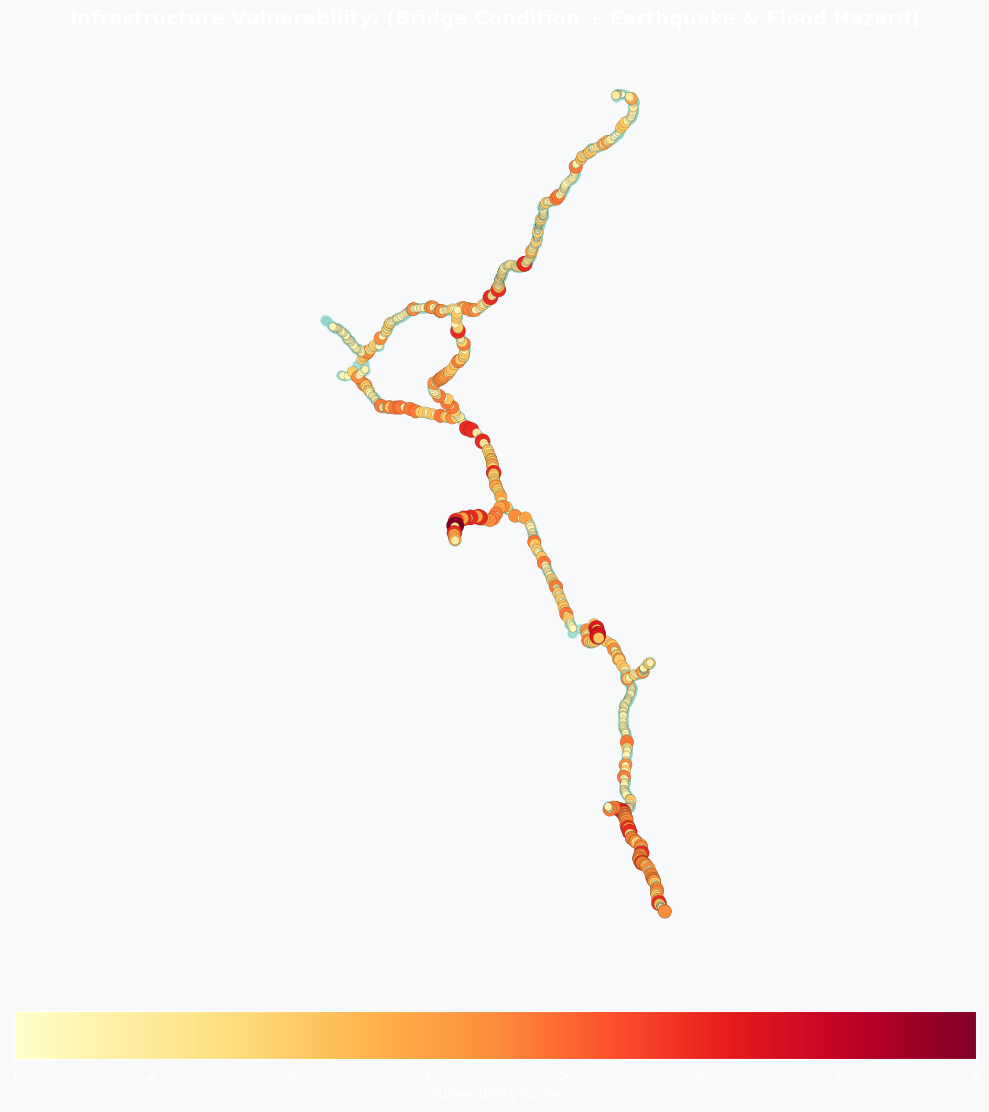

In [30]:
import matplotlib.pyplot as plt

# Separate the network components
links = gdf_roads[gdf_roads['model_type'] == 'link']
bridges = gdf_roads[gdf_roads['model_type'] == 'bridge']

fig, ax = plt.subplots(figsize=(10, 12), facecolor='#f8f9fa')

# Plot the Road Network
links.plot(ax=ax, linewidth=1.5, alpha=0.7, label='Road Segments', zorder=1)

# Plot Bridges
im = bridges.plot(
    ax=ax,
    column='vulnerability_score',
    cmap='YlOrRd', # yellow-orange-red
    markersize=bridges['vulnerability_score'] * 20,
    edgecolor='black',
    linewidth=0.1,
    legend=True,
    legend_kwds={'label': "Vulnerability Score", 'orientation': "horizontal", 'pad': 0.05},
    zorder=2
)

# Context and visualisation
ax.set_title("Infrastructure Vulnerability: (Bridge Condition + Earthquake & Flood Hazard)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [38]:
# 3. Filter and Rank Top-10
top_10_vulnerable = gdf_roads.nlargest(10, 'vulnerability_score')

# Sort by the integrated vulnerability score
top_10_table = gdf_roads.sort_values(by='vulnerability_score', ascending=False).head(10)

# Identify the dominant hazard for the 'Primary Risk' column
def identify_risk(row):
    if row['flood_mult'] >= row['seismic_mult']:
        return f"Flood (x{row['flood_mult']:.1f})"
    return f"EQ Zone {row['eq_zone']} (x{row['seismic_mult']:.1f})"

top_10_table['primary_risk'] = top_10_table.apply(identify_risk, axis=1)

# Display the clean table
print(top_10_table[['road', 'id', 'model_type', 'condition', 'primary_risk', 'vulnerability_score']])
top_10_table

      road     id model_type condition        primary_risk  \
2604  N104  12604     bridge         D  EQ Zone III (x2.0)   
2646  N107  12646     bridge         D        Flood (x1.6)   
858     N1  10858     bridge         D        Flood (x1.6)   
2648  N107  12648     bridge         D        Flood (x1.6)   
2650  N107  12650     bridge         D        Flood (x1.6)   
2638  N107  12638     bridge         D        Flood (x1.6)   
1737    N2  11737     bridge         C        Flood (x2.0)   
166     N1  10166     bridge         C        Flood (x2.0)   
2580  N104  12580     bridge         C  EQ Zone III (x2.0)   
944     N1  10944     bridge         D   EQ Zone II (x1.5)   

      vulnerability_score  
2604                  8.0  
2646                  6.4  
858                   6.4  
2648                  6.4  
2650                  6.4  
2638                  6.4  
1737                  6.0  
166                   6.0  
2580                  6.0  
944                   6.0  


,Unnamed: 0,length,condition,lat,lon,intersection,model_type,id,road,name,...,flood_cat,index_right,eq_hazard,eq_zone,int_cond_score,seismic_mult,flood_mult,max_hazard_mult,vulnerability_score,primary_risk
2604,2604,6.20,D,22.909768,91.101541,NaN,bridge,12604,N104,NaN,...,0.0,3.0,0.3,III,4.0,2.0,1.0,2.0,8.0,EQ Zone III (x2.0)
2646,2646,73.00,D,22.340325,91.917067,NaN,bridge,12646,N107,NaN,...,5.0,0.0,0.6,II,4.0,1.5,1.6,1.6,6.4,Flood (x1.6)
858,858,10.00,D,21.406361,92.058047,NaN,bridge,10858,N1,NaN,...,5.0,0.0,0.6,II,4.0,1.5,1.6,1.6,6.4,Flood (x1.6)
2648,2648,2.40,D,22.329087,91.914577,NaN,bridge,12648,N107,NaN,...,5.0,0.0,0.6,II,4.0,1.5,1.6,1.6,6.4,Flood (x1.6)
2650,2650,4.50,D,22.326371,91.915321,NaN,bridge,12650,N107,NaN,...,5.0,0.0,0.6,II,4.0,1.5,1.6,1.6,6.4,Flood (x1.6)
2638,2638,5.60,D,22.369956,91.907370,NaN,bridge,12638,N107,NaN,...,5.0,0.0,0.6,II,4.0,1.5,1.6,1.6,6.4,Flood (x1.6)
1737,1737,2.00,C,24.286237,91.498186,NaN,bridge,11737,N2,NaN,...,4.0,2.0,1.0,I,3.0,1.0,2.0,2.0,6.0,Flood (x2.0)
166,166,35.97,C,23.421249,91.167894,NaN,bridge,10166,N1,NaN,...,4.0,0.0,0.6,II,3.0,1.5,2.0,2.0,6.0,Flood (x2.0)
2580,2580,2.70,C,22.952665,91.188394,NaN,bridge,12580,N104,NaN,...,3.0,3.0,0.3,III,3.0,2.0,1.3,2.0,6.0,EQ Zone III (x2.0)
944,944,11.20,D,21.321109,92.088884,NaN,bridge,10944,N1,NaN,...,0.0,0.0,0.6,II,4.0,1.5,1.0,1.5,6.0,EQ Zone II (x1.5)


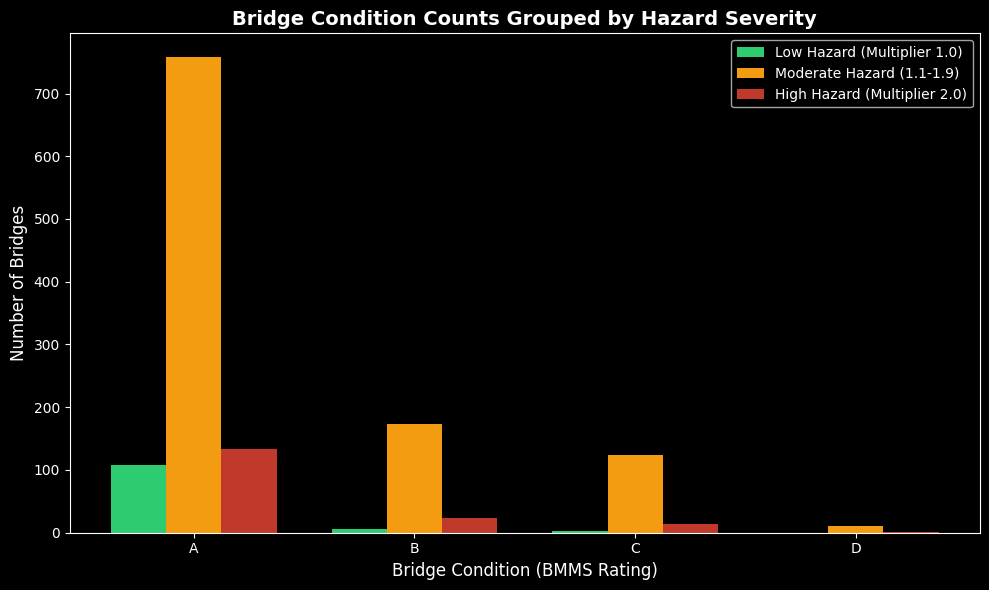

In [40]:
import numpy as np

# Focus on actual bridges
bridges_only = gdf_roads[gdf_roads['model_type'] == 'bridge']

# Define Hazard Tiers for coloring
low_hazard = bridges_only[bridges_only['max_hazard_mult'] <= 1.0]
med_hazard = bridges_only[(bridges_only['max_hazard_mult'] > 1.0) & (bridges_only['max_hazard_mult'] < 2.0)]
high_hazard = bridges_only[bridges_only['max_hazard_mult'] >= 2.0]

fig, ax = plt.subplots(figsize=(10, 6))

labels = ['A', 'B', 'C', 'D']
x = np.arange(len(labels))
width = 0.25

# Count frequencies for each hazard group
def get_counts(df):
    return [len(df[df['condition'] == l]) for l in labels]

ax.bar(x - width, get_counts(low_hazard), width, label='Low Hazard (Multiplier 1.0)', color='#2ecc71')
ax.bar(x, get_counts(med_hazard), width, label='Moderate Hazard (1.1-1.9)', color='#f39c12')
ax.bar(x + width, get_counts(high_hazard), width, label='High Hazard (Multiplier 2.0)', color='#c0392b')

ax.set_title('Bridge Condition Counts Grouped by Hazard Severity', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Bridge Condition (BMMS Rating)', fontsize=12)
ax.set_ylabel('Number of Bridges', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('histogram_condition_hazard.png')
plt.show()

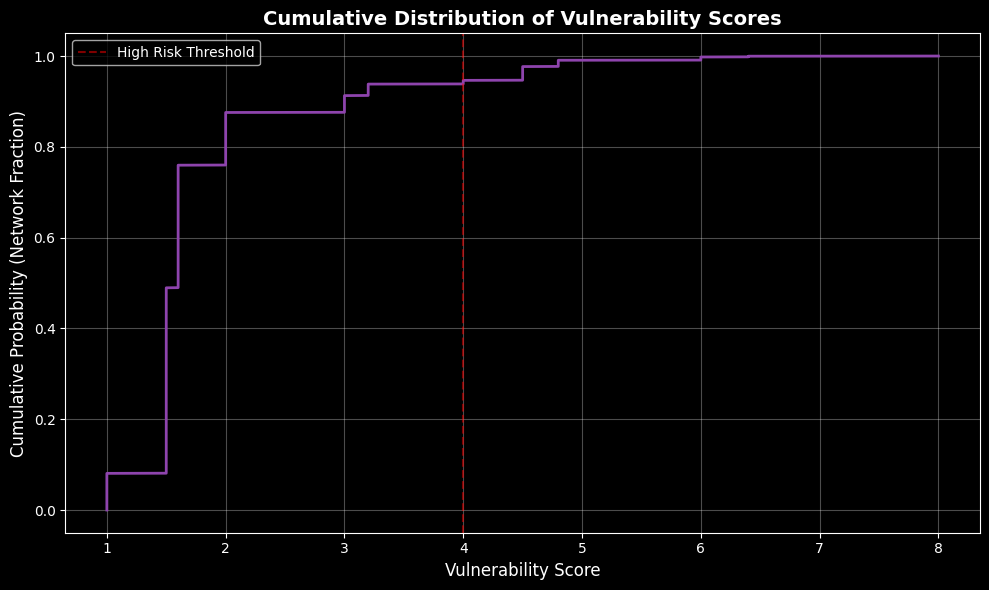

In [42]:
# Sort all scores
sorted_scores = np.sort(gdf_roads['vulnerability_score'].dropna())
p = 1. * np.arange(len(sorted_scores)) / (len(sorted_scores) - 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sorted_scores, p, color='#8e44ad', linewidth=2)

# Mark the "High Risk" threshold (e.g., Score > 4.0)
ax.axvline(4.0, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
ax.set_title('Cumulative Distribution of Vulnerability Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Vulnerability Score', fontsize=12)
ax.set_ylabel('Cumulative Probability (Network Fraction)', fontsize=12)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('vulnerability_cdf.png')
plt.show()

# Criticality Score